In [2]:
import os, json, numpy as np, pandas as pd, torch, seaborn as sns, matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, f1_score,
                             precision_score, recall_score)
from datasets import Dataset
import evaluate
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, DataCollatorWithPadding)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from pathlib import Path

In [27]:
MODEL_NAME = "nlpaueb/legal-bert-base-uncased"
TRAIN_CSV = r"D:\VScodefiles\NLPPRO\train.csv"
VAL_CSV   = r"D:\VScodefiles\NLPPRO\val.csv"
TEST_CSV  = r"D:\VScodefiles\NLPPRO\test.csv"
OUTPUT_DIR = r"D:\VScodefiles\NLPPRO\outputs\legalbert_eval"
os.makedirs(OUTPUT_DIR, exist_ok=True)
EPOCHS = 5  # Reduced epochs to prevent overfitting initially
BATCH_SIZE = 16
MAX_LEN = 512  # Increased max length for legal text
SEED = 42
LEARNING_RATE = 2e-5  # Lower learning rate for fine-tuning
WARMUP_STEPS = 500
WEIGHT_DECAY = 0.01
torch.manual_seed(SEED)
np.random.seed(SEED)

In [6]:
import pandas as pd
from pathlib import Path
files = [Path(r"D:\VScodefiles\NLPPRO\train.csv"), Path(r"D:\VScodefiles\NLPPRO\val.csv"), Path(r"D:\VScodefiles\NLPPRO\test.csv")]
for f in files:
    print("=== Checking", f, "exists:", f.exists())
    if not f.exists(): 
        continue
    df = pd.read_csv(f)
    # prefer text_clean if present
    col = "text" if "text" in df.columns else ("text_clean" if "text_clean" in df.columns else None)
    print("Using text column:", col)
    if col is None:
        print("ERROR: No 'text' or 'text_clean' column found in", f)
        continue
    # Basic counts
    total = len(df)
    nulls = df[col].isna().sum()
    print("Rows:", total, "Nulls in text column:", nulls)
    # show first 10 types and examples
    types = df[col].apply(lambda x: type(x)).value_counts().to_dict()
    print("Types in text column (counts):", types)
    # sample problematic rows (non-str or empty)
    mask = df[col].apply(lambda x: not isinstance(x, str) or str(x).strip()=="" )
    bad = df[mask].head(10)
    print("First problematic rows (index, type, preview):")
    for idx, row in bad.iterrows():
        val = row[col]
        print(idx, type(val), repr(str(val))[:200])
    print()


=== Checking D:\VScodefiles\NLPPRO\train.csv exists: True
Using text column: text
Rows: 4164 Nulls in text column: 0
Types in text column (counts): {<class 'str'>: 4164}
First problematic rows (index, type, preview):

=== Checking D:\VScodefiles\NLPPRO\val.csv exists: True
Using text column: text
Rows: 520 Nulls in text column: 0
Types in text column (counts): {<class 'str'>: 520}
First problematic rows (index, type, preview):

=== Checking D:\VScodefiles\NLPPRO\test.csv exists: True
Using text column: text
Rows: 521 Nulls in text column: 0
Types in text column (counts): {<class 'str'>: 521}
First problematic rows (index, type, preview):



In [28]:
# --- Load Data ---
def load_df(path):
    df = pd.read_csv(path)
    if "text_clean" in df.columns:
        df["text"] = df["text_clean"]
    return df

train_df = load_df(TRAIN_CSV)
val_df   = load_df(VAL_CSV)
test_df  = load_df(TEST_CSV)

# --- Label Encoding ---
le = LabelEncoder()
le.fit(train_df['label'])
train_df['label_id'] = le.transform(train_df['label'])
val_df['label_id'] = le.transform(val_df['label'])
test_df['label_id'] = le.transform(test_df['label'])

label_names = list(le.classes_)
num_labels = len(label_names)
print(f"Classes: {label_names}, Number of labels: {num_labels}")

# --- Compute Class Weights ---
class_weights = compute_class_weight('balanced', classes=np.unique(train_df['label_id']), y=train_df['label_id'])
class_weights = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights: {class_weights}")

# Save label map
label_map = {"classes": label_names, "class_weights": class_weights.tolist()}
with open(Path(OUTPUT_DIR) / "label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)

# --- HuggingFace Dataset Preparation ---
def df_to_hf_dataset(df):
    # Clean text column
    df['text'] = df['text'].fillna("").astype(str).apply(lambda x: x.strip())
    df = df[df['text'] != ""].reset_index(drop=True) # Remove empty texts
    return Dataset.from_pandas(df[['text', 'label_id']])

train_ds = df_to_hf_dataset(train_df)
val_ds = df_to_hf_dataset(val_df)
test_ds = df_to_hf_dataset(test_df)

print(f"\nDataset sizes - Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

# --- Tokenizer and Preprocessing ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(batch):
    texts = [str(t) for t in batch["text"]]
    encoding = tokenizer(
        texts,
        truncation=True,
        padding=True,  # Use dynamic padding for efficiency
        max_length=MAX_LEN,
        return_tensors=None  # Let the data collator handle tensors
    )
    return encoding

# Apply preprocessing
train_ds = train_ds.map(preprocess, batched=True)
val_ds = val_ds.map(preprocess, batched=True)
test_ds = test_ds.map(preprocess, batched=True)

# Rename label column
train_ds = train_ds.rename_column("label_id", "labels")
val_ds = val_ds.rename_column("label_id", "labels")
test_ds = test_ds.rename_column("label_id", "labels")

# Set format for PyTorch
train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
val_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print("Tokenization and formatting complete.")
print("Example tokenized entry:", {k: v for k, v in train_ds[0].items() if k != 'text'})

Classes: ['Ambiguous', 'Compliant', 'Non-Compliant'], Number of labels: 3
Class weights: tensor([0.7229, 0.7229, 4.2840])

Dataset sizes - Train: 4163, Val: 520, Test: 521


Map:   0%|          | 0/4163 [00:00<?, ? examples/s]

Map:   0%|          | 0/520 [00:00<?, ? examples/s]

Map:   0%|          | 0/521 [00:00<?, ? examples/s]

Tokenization and formatting complete.
Example tokenized entry: {'labels': tensor(1), 'input_ids': tensor([  101,   217,  2143,   586,   115,   207, 13018,  3640,   223,  3915,
          218,  1701,  3169,   357,   117,   102,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,  

In [31]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(self.args.device) # Ensure weights are on correct device

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Accept and potentially use any extra kwargs passed by the Trainer
        # For example, 'num_items_in_batch' might be passed, but we don't need it here.
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        if labels is not None:
            loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        else:
            loss = outputs.loss if outputs.loss is not None else None

        return (loss, outputs) if return_outputs else loss

# --- Metrics Calculation ---
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    acc = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average="macro")
    f1_weighted = f1_score(labels, predictions, average="weighted")
    precision = precision_score(labels, predictions, average="macro", zero_division=0)
    recall = recall_score(labels, predictions, average="macro", zero_division=0)
    
    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision': precision,
        'recall': recall
    }

# --- Data Collator ---
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# --- Model Initialization ---
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    problem_type="single_label_classification"  # Explicitly set problem type
)

# --- Training Arguments ---
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=WARMUP_STEPS,
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,  # Keep only last 2 checkpoints
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    dataloader_num_workers=2,  # Use multiple workers if data loading is slow
    fp16=torch.cuda.is_available(),  # Use mixed precision if GPU is available
    report_to=None  # Disable wandb logging if not needed
)

# --- Initialize Trainer ---
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

# --- Start Training ---
print("🚀 Starting training...")
train_result = trainer.train()
trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)

# Print final metrics
print("\n--- Training Results ---")
for key, value in train_result.metrics.items():
    print(f"{key}: {value:.4f}")

# Evaluate on validation set
print("\n--- Final Evaluation on Validation Set ---")
eval_results = trainer.evaluate()
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/legal-bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\K8IN\AppData\Local\Temp\ipykernel_11624\44856340.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
C:\Users\K8IN\AppData\Local\Temp\ipykernel_11624\44856340.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.

🚀 Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,1.023800,1.013510,0.605769,0.414779,0.574309,0.418360,0.437500
2,0.662800,0.848659,0.682692,0.630573,0.670110,0.671462,0.625000
3,0.628900,0.624234,0.753846,0.719016,0.751658,0.720948,0.725000
4,0.263200,0.621564,0.778846,0.767944,0.777311,0.776678,0.763889
5,0.143700,0.667883,0.776923,0.755540,0.776902,0.755530,0.755556



--- Training Results ---
train_runtime: 1982.8829
train_samples_per_second: 10.4970
train_steps_per_second: 0.6580
total_flos: 5476705790008320.0000
train_loss: 0.6141
epoch: 5.0000

--- Final Evaluation on Validation Set ---


eval_loss: 0.6216
eval_accuracy: 0.7788
eval_f1_macro: 0.7679
eval_f1_weighted: 0.7773
eval_precision: 0.7767
eval_recall: 0.7639
eval_runtime: 39.5589
eval_samples_per_second: 13.1450
eval_steps_per_second: 0.8340
epoch: 5.0000


In [32]:
# ------------------------------------------------------------
# TEST EVALUATION
# ------------------------------------------------------------
print("\n📊 Evaluating on test set...")
preds_output = trainer.predict(test_ds)
preds = np.argmax(preds_output.predictions, axis=-1)
labels = preds_output.label_ids

report = classification_report(labels, preds, target_names=label_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(f"{OUTPUT_DIR}/classification_report.csv")
print(report_df)


📊 Evaluating on test set...
               precision    recall  f1-score     support
Ambiguous       0.805128  0.654167  0.721839  240.000000
Compliant       0.721254  0.862500  0.785579  240.000000
Non-Compliant   0.769231  0.731707  0.750000   41.000000
accuracy        0.756238  0.756238  0.756238    0.756238
macro avg       0.765204  0.749458  0.752473  521.000000
weighted avg    0.763667  0.756238  0.753417  521.000000
               precision    recall  f1-score     support
Ambiguous       0.805128  0.654167  0.721839  240.000000
Compliant       0.721254  0.862500  0.785579  240.000000
Non-Compliant   0.769231  0.731707  0.750000   41.000000
accuracy        0.756238  0.756238  0.756238    0.756238
macro avg       0.765204  0.749458  0.752473  521.000000
weighted avg    0.763667  0.756238  0.753417  521.000000


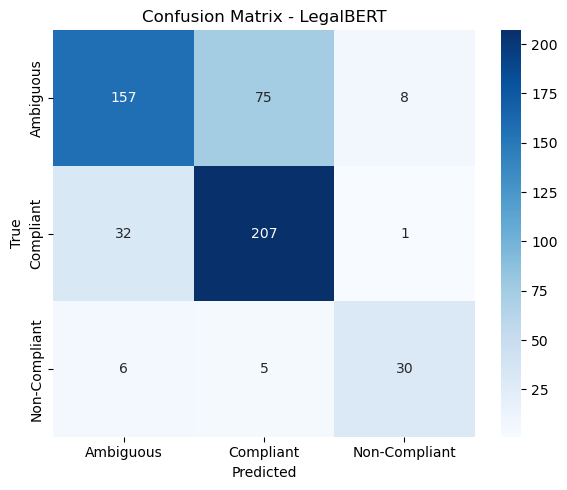

In [33]:
# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - LegalBERT")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png")
plt.show()

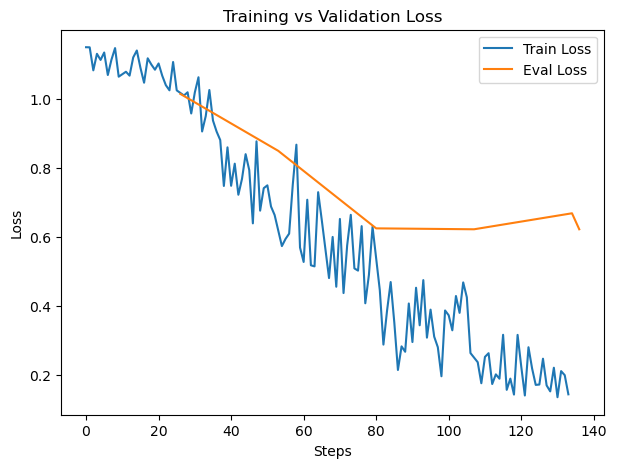

In [34]:
# ------------------------------------------------------------
# TRAINING CURVES
# ------------------------------------------------------------
if "loss" in train_output.metrics:
    train_loss = train_output.metrics["loss"]
if "eval_loss" in train_output.metrics:
    eval_loss = train_output.metrics["eval_loss"]

metrics_df = pd.DataFrame(trainer.state.log_history)
metrics_df.to_csv(f"{OUTPUT_DIR}/training_metrics_log.csv")

plt.figure(figsize=(7,5))
sns.lineplot(x=metrics_df.index, y=metrics_df["loss"], label="Train Loss")
if "eval_loss" in metrics_df.columns:
    sns.lineplot(x=metrics_df.index, y=metrics_df["eval_loss"], label="Eval Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.savefig(f"{OUTPUT_DIR}/training_loss_curve.png")
plt.show()

In [43]:
# ------------------------------------------------------------
# SAVE FINAL METRICS
# ------------------------------------------------------------
final_metrics = {
    "accuracy": accuracy_score(labels, preds),
    "precision_macro": precision_score(labels, preds, average='macro'),
    "recall_macro": recall_score(labels, preds, average='macro'),
    "f1_macro": f1_score(labels, preds, average='macro'),
    "f1_weighted": f1_score(labels, preds, average='weighted')
}
json.dump(final_metrics, open(f"{OUTPUT_DIR}/final_metrics.json", "w"), indent=2)
print("\n✅ Saved evaluation metrics and plots to:", OUTPUT_DIR)


✅ Saved evaluation metrics and plots to: D:\VScodefiles\NLPPRO\outputs\legalbert_eval


In [7]:
import os
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [8]:
# --- Load environment variables from .env file ---
from dotenv import load_dotenv
load_dotenv() # This loads the variables from the .env file

# --- Load the dataset with true labels ---
df = pd.read_csv(r"D:\VScodefiles\NLPPRO\dataset_after_balance.csv")  # Ensure this has columns: 'text' and 'label'
labels_true = df['label'].tolist()
classes = sorted(df['label'].unique().tolist()) # Get unique classes from the dataset
print("Classes:", classes)
print(f"Total samples: {len(labels_true)}")

Classes: ['Ambiguous', 'Compliant', 'Non-Compliant']
Total samples: 5205


In [9]:
# --- Utility to compute metrics given predictions ---
def eval_metrics(y_true, y_pred, labels=classes):
    # Handle cases where prediction might be an unexpected label not in classes
    # Filter out such predictions for metric calculation based on known classes
    valid_indices = [i for i, p in enumerate(y_pred) if p in labels]
    y_true_filtered = [y_true[i] for i in valid_indices]
    y_pred_filtered = [y_pred[i] for i in valid_indices]

    if not y_pred_filtered:
        print("Warning: No valid predictions found for metric calculation.")
        return {k: 0.0 for k in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'precision_weighted', 'recall_weighted', 'f1_weighted']}

    acc = accuracy_score(y_true_filtered, y_pred_filtered)
    prec_macro = precision_score(y_true_filtered, y_pred_filtered, average='macro', labels=labels, zero_division=0)
    recall_macro = recall_score(y_true_filtered, y_pred_filtered, average='macro', labels=labels, zero_division=0)
    f1_macro = f1_score(y_true_filtered, y_pred_filtered, average='macro', labels=labels, zero_division=0)
    prec_weighted = precision_score(y_true_filtered, y_pred_filtered, average='weighted', labels=labels, zero_division=0)
    recall_weighted = recall_score(y_true_filtered, y_pred_filtered, average='weighted', labels=labels, zero_division=0)
    f1_weighted = f1_score(y_true_filtered, y_pred_filtered, average='weighted', labels=labels, zero_division=0)
    report = classification_report(y_true_filtered, y_pred_filtered, labels=labels, zero_division=0, output_dict=True)
    return {
        'accuracy': acc,
        'precision_macro': prec_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': prec_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
        'report': report
    }
# --- Helper to plot confusion matrix ---
def plot_confusion_mat(y_true, y_pred, labels, title, save_path):
    # Filter predictions to only include known labels for plotting
    valid_indices = [i for i, p in enumerate(y_pred) if p in labels]
    y_true_filtered = [y_true[i] for i in valid_indices]
    y_pred_filtered = [y_pred[i] for i in valid_indices]

    if not y_pred_filtered:
        print(f"Warning: No valid predictions for '{title}'. Cannot plot confusion matrix.")
        # Create an empty plot or a simple message
        plt.figure(figsize=(8,6))
        plt.text(0.5, 0.5, 'No valid predictions to plot', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
        plt.title(title)
        plt.axis('off')
        plt.savefig(save_path)
        plt.close()
        return

    cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=labels)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

# --- Prepare containers ---
results_all = {}


In [10]:
# ============================================================
# 1) LegalBERT (your fine-tuned model) inference
# ============================================================
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_dir = r"D:\VScodefiles\NLPPRO\outputs\legalbert_eval"   # adjust if different
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

preds = []
batch_size = 32
for i in tqdm(range(0, len(df), batch_size), desc="LegalBERT"):
    batch = df['text'].iloc[i:i+batch_size].tolist() # Use iloc for safe slicing
    enc = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device) # Use 512 as per training
    with torch.no_grad():
        logits = model(**enc).logits
        batch_pred = torch.argmax(logits, dim=-1).cpu().numpy().tolist()
    preds.extend(batch_pred)

# Map numeric preds to class labels
label_map = json.load(open(os.path.join(model_dir, "label_map.json")))
class_names = label_map['classes']
y_pred = [class_names[p] for p in preds]

metrics = eval_metrics(labels_true, y_pred)
results_all['LegalBERT'] = metrics
plot_confusion_mat(labels_true, y_pred, classes, "LegalBERT Confusion Matrix", "cm_legalbert.png")
print("LegalBERT metrics:", {k: v for k, v in metrics.items() if k != 'report'}) # Exclude detailed report from print

LegalBERT: 100%|██████████| 163/163 [00:43<00:00,  3.74it/s]



LegalBERT metrics: {'accuracy': 0.9018251681075888, 'precision_macro': 0.9107604611542861, 'recall_macro': 0.905082304526749, 'f1_macro': 0.9063683756582677, 'precision_weighted': 0.9053026551990123, 'recall_weighted': 0.9018251681075888, 'f1_weighted': 0.9014292528840089}


In [14]:
# ============================================================
# 2) Hugging Face Model: CardiffNLP Twitter RoBERTa
# ============================================================
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer

print("\n🔄 Loading RoBERTa sentiment model...")

# Load model and tokenizer
model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
hf_model = AutoModelForSequenceClassification.from_pretrained(model_name)
hf_tokenizer = AutoTokenizer.from_pretrained(model_name)

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
hf_model = hf_model.to(device)
hf_model.eval()  # Set to evaluation mode

# Get model's prediction labels
label2id = hf_model.config.label2id
id2label = {v: k for k, v in label2id.items()}
print("Model labels:", id2label)

def predict_sentiment_batch(texts, max_length=512):
    try:
        # Tokenize
        inputs = hf_tokenizer(texts, padding=True, truncation=True, max_length=max_length, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Get predictions
        with torch.no_grad():
            outputs = hf_model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1)
        
        # Convert to labels
        return [id2label[pred.item()] for pred in predictions]
    except Exception as e:
        print(f"Error in predict_sentiment_batch: {str(e)}")
        return ["ERROR"] * len(texts)

def map_sentiment_to_class(sentiment_label):
    """Map sentiment model outputs to your classes"""
    # Print unique classes to help with mapping
    if not hasattr(map_sentiment_to_class, 'printed_classes'):
        print("Available target classes:", classes)
        map_sentiment_to_class.printed_classes = True
    
    # Map RoBERTa sentiment labels to your classes
    if sentiment_label == 'positive':
        return classes[-1]  # Last class
    elif sentiment_label == 'negative':
        return classes[0]   # First class
    elif sentiment_label == 'neutral':
        return classes[min(1, len(classes)-1)]  # Second class or last if only 2
    else:
        return classes[0]  # Default to first class

print("\n🔄 Processing texts with RoBERTa sentiment model...")
preds_hf_sentiment = []
batch_size = 16  # Smaller batch size for stability

for i in tqdm(range(0, len(df), batch_size), desc="RoBERTa Sentiment"):
    # Get batch
    batch_texts = df['text'].iloc[i:i+batch_size].tolist()
    
    # Get predictions for batch
    batch_sentiments = predict_sentiment_batch(batch_texts)
    
    # Map to your classes
    batch_preds = [map_sentiment_to_class(sent) for sent in batch_sentiments]
    preds_hf_sentiment.extend(batch_preds)
    
    # Print sample predictions periodically
    if i % 100 == 0 and batch_preds:
        print(f"\nSample predictions from batch {i}:")
        for text, pred in zip(batch_texts[:2], batch_preds[:2]):
            print(f"Text: {text[:100]}...")
            print(f"Predicted: {pred}\n")

# Ensure predictions array is same length as input
if len(preds_hf_sentiment) > len(df):
    preds_hf_sentiment = preds_hf_sentiment[:len(df)]
elif len(preds_hf_sentiment) < len(df):
    preds_hf_sentiment.extend([classes[0]] * (len(df) - len(preds_hf_sentiment)))

# Calculate metrics
metrics_hf_sentiment = eval_metrics(labels_true, preds_hf_sentiment)
results_all['HuggingFace_Sentiment'] = metrics_hf_sentiment

# Plot confusion matrix
plot_confusion_mat(labels_true, preds_hf_sentiment, classes, 
                  "RoBERTa Sentiment Model Confusion Matrix", 
                  "cm_roberta_sentiment.png")

# Print results
print("\n📊 RoBERTa Sentiment Model Results:")
print("Metrics:", {k: v for k, v in metrics_hf_sentiment.items() if k != 'report'})

# Analyze predictions
pred_dist = pd.Series(preds_hf_sentiment).value_counts()
print("\nPrediction Distribution:")
print(pred_dist)

# Print comparison of some predictions
print("\nSample Predictions vs True Labels:")
sample_idx = np.random.choice(len(df), 5, replace=False)
for idx in sample_idx:
    print(f"\nText: {df['text'].iloc[idx][:100]}...")
    print(f"True: {labels_true[idx]}")
    print(f"Predicted: {preds_hf_sentiment[idx]}")


🔄 Loading RoBERTa sentiment model...


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Model labels: {0: 'negative', 1: 'neutral', 2: 'positive'}

🔄 Processing texts with RoBERTa sentiment model...


RoBERTa Sentiment:   1%|          | 2/326 [00:00<00:25, 12.60it/s]

Available target classes: ['Ambiguous', 'Compliant', 'Non-Compliant']

Sample predictions from batch 0:
Text: Oracle employees are obligated to follow rules for password length and complexity, and keep their pa...
Predicted: Compliant

Text: • COOKIES, BEACONS, AND SIMILAR TECHNOLOGIES • CONTACT US • US SUPPLEMENT TO THE SAMSUNG PRIVACY POL...
Predicted: Compliant



...


Sample predictions from batch 4400:
Text: Who your friends or followers are, and what they do on our Products Information from the phone, comp...
Predicted: Compliant

Text: We also receive non-personal data, such as aggregated or de-identified demographic/profile data, fro...
Predicted: Compliant



RoBERTa Sentiment:  93%|█████████▎| 302/326 [00:32<00:02,  8.20it/s]


Sample predictions from batch 4800:
Text: A copy of the audit results related to compliance with this Processor Code will be provided to the L...
Predicted: Compliant

Text: now for limited-time offers!...
Predicted: Compliant



RoBERTa Sentiment: 100%|██████████| 326/326 [00:36<00:00,  8.99it/s]




Sample predictions from batch 5200:
Text: Is Microsoft subject to a legal, contractual, or similar obligation to retain or delete the data?...
Predicted: Compliant

Text: You can find further information about these recipients in Section VIII....
Predicted: Compliant


📊 RoBERTa Sentiment Model Results:
Metrics: {'accuracy': 0.44245917387127764, 'precision_macro': 0.26231648803700874, 'recall_macro': 0.3198611111111111, 'f1_macro': 0.22357840450397015, 'precision_weighted': 0.36285854252957983, 'recall_weighted': 0.44245917387127764, 'f1_weighted': 0.3092727209276821}

Prediction Distribution:
Compliant        4795
Non-Compliant     216
Ambiguous         194
Name: count, dtype: int64

Sample Predictions vs True Labels:

Text: Unrestricted| © Siemens 2025 AVA-EF ATS EN 2025 01 p 10 / 10...
True: Compliant
Predicted: Compliant

Text: We will post any privacy policy changes on this page and, if the changes are significant, we will pr...
True: Compliant
Predicted: Compliant

Text: If you 

In [21]:
# ============================================================
# 3) Hugging Face Model: InLegalBERT
# ============================================================
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

print("\n🔄 Loading InLegalBERT model...")

try:
    # Load the base InLegalBERT model and tokenizer
    model_name_inlegalbert = "law-ai/InLegalBERT"  # This is the correct model name
    inlegalbert_base = AutoModel.from_pretrained(model_name_inlegalbert)
    inlegalbert_tokenizer = AutoTokenizer.from_pretrained(model_name_inlegalbert)
    
    # Create a classification head
    class LegalBERTClassifier(torch.nn.Module):
        def __init__(self, base_model, num_labels):
            super().__init__()
            self.base_model = base_model
            self.dropout = torch.nn.Dropout(0.1)
            self.classifier = torch.nn.Linear(base_model.config.hidden_size, num_labels)
        
        def forward(self, **inputs):
            # Get base model outputs
            outputs = self.base_model(**inputs)
            # Use the [CLS] token representation
            pooled_output = outputs[0][:, 0]
            # Apply dropout and classification
            pooled_output = self.dropout(pooled_output)
            logits = self.classifier(pooled_output)
            return logits

    # Create the complete model
    inlegalbert_model = LegalBERTClassifier(inlegalbert_base, len(classes))
    inlegalbert_model = inlegalbert_model.to(device)
    inlegalbert_model.eval()
    print("InLegalBERT model loaded successfully with classification head.")

    def predict_inlegalbert_batch(texts, max_length=512):
        try:
            # Tokenize
            inputs = inlegalbert_tokenizer(
                texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}

            # Get predictions
            with torch.no_grad():
                logits = inlegalbert_model(**inputs)
                predictions = torch.argmax(logits, dim=-1)

            # Map numeric predictions to class labels
            return [classes[pred.item()] for pred in predictions]
        except Exception as e:
            print(f"Error in predict_inlegalbert_batch: {str(e)}")
            return [classes[0]] * len(texts)

    print("\n🔄 Processing texts with InLegalBERT model...")
    preds_inlegalbert = []
    batch_size = 8  # Smaller batch size to prevent OOM

    for i in tqdm(range(0, len(df), batch_size), desc="InLegalBERT"):
        batch_texts = df['text'].iloc[i:i+batch_size].tolist()
        batch_preds = predict_inlegalbert_batch(batch_texts)
        preds_inlegalbert.extend(batch_preds)
        
        # Print sample predictions periodically
        if i % 50 == 0 and batch_preds:
            print(f"\nSample predictions from batch {i}:")
            for text, pred in zip(batch_texts[:1], batch_preds[:1]):
                print(f"Text: {text[:100]}...")
                print(f"Predicted: {pred}")

    # Calculate metrics
    metrics_inlegalbert = eval_metrics(labels_true, preds_inlegalbert)
    results_all['InLegalBERT'] = metrics_inlegalbert
    
    # Plot confusion matrix
    plot_confusion_mat(labels_true, preds_inlegalbert, classes, 
                      "InLegalBERT Confusion Matrix", 
                      "cm_inlegalbert.png")
    
    # Print results
    print("\n📊 InLegalBERT Model Results:")
    print("Metrics:", {k: v for k, v in metrics_inlegalbert.items() if k != 'report'})
    
    # Analyze predictions
    pred_dist = pd.Series(preds_inlegalbert).value_counts()
    print("\nPrediction Distribution:")
    print(pred_dist)

except Exception as e:
    print(f"Error setting up InLegalBERT: {str(e)}")
    print("InLegalBERT model could not be loaded. Skipping.")


🔄 Loading InLegalBERT model...


config.json:   0%|          | 0.00/671 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/534M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/516 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...


Sample predictions from batch 4800:
Text: A copy of the audit results related to compliance with this Processor Code will be provided to the L...
Predicted: Ambiguous


InLegalBERT:  93%|█████████▎| 607/651 [00:28<00:02, 18.90it/s]


Sample predictions from batch 5000:
Text: If you live in Canada, you can use the Digital Advertising Alliance of Canada industry opt-out platf...
Predicted: Ambiguous


InLegalBERT: 100%|██████████| 651/651 [00:30<00:00, 21.48it/s]




Sample predictions from batch 5200:
Text: Is Microsoft subject to a legal, contractual, or similar obligation to retain or delete the data?...
Predicted: Ambiguous

📊 InLegalBERT Model Results:
Metrics: {'accuracy': 0.4670509125840538, 'precision_macro': 0.365871378026748, 'recall_macro': 0.34311213991769546, 'f1_macro': 0.27378148368431104, 'precision_weighted': 0.47165188839499655, 'recall_weighted': 0.4670509125840538, 'f1_weighted': 0.36630380363336307}

Prediction Distribution:
Ambiguous        4661
Compliant         455
Non-Compliant      89
Name: count, dtype: int64

📊 InLegalBERT Model Results:
Metrics: {'accuracy': 0.4670509125840538, 'precision_macro': 0.365871378026748, 'recall_macro': 0.34311213991769546, 'f1_macro': 0.27378148368431104, 'precision_weighted': 0.47165188839499655, 'recall_weighted': 0.4670509125840538, 'f1_weighted': 0.36630380363336307}

Prediction Distribution:
Ambiguous        4661
Compliant         455
Non-Compliant      89
Name: count, dtype: int64


In [30]:
# ============================================================
# 5) Hugging Face Zero-Shot Model (classification) - Requires 'transformers' package
# ============================================================
from transformers import pipeline

# Using a strong zero-shot model, e.g., facebook/bart-large-mnli
hf_model_name_zeroshot = "facebook/bart-large-mnli"
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model=hf_model_name_zeroshot,
    device=0 if torch.cuda.is_available() else -1 # Use GPU if available
)

preds_hf_zeroshot = []
for text in tqdm(df['text'], desc="HF_ZeroShot"):
    try:
        # Ensure text is a string
        text_str = str(text) if text is not None else ""
        result = zero_shot_classifier(text_str, candidate_labels=classes)
        # The pipeline returns the most likely label
        lbl = result['labels'][0]
        preds_hf_zeroshot.append(lbl)
    except Exception as e:
        print(f"HF Zero-Shot error for text '{text[:50]}...': {e}")
        preds_hf_zeroshot.append("") # Or handle differently

metrics_hf_zeroshot = eval_metrics(labels_true, preds_hf_zeroshot)
results_all['HuggingFace_ZeroShot'] = metrics_hf_zeroshot
plot_confusion_mat(labels_true, preds_hf_zeroshot, classes, "HF ZeroShot Confusion Matrix", "cm_hf_zeroshot.png")
print("HuggingFace ZeroShot metrics:", {k: v for k, v in metrics_hf_zeroshot.items() if k != 'report'})

config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
HF_ZeroShot: 100%|██████████| 5205/5205 [32:14<00:00,  2.69it/s]



HuggingFace ZeroShot metrics: {'accuracy': 0.9988472622478386, 'precision_macro': 0.999168744804655, 'recall_macro': 0.9977983539094649, 'f1_macro': 0.9984807615558656, 'precision_weighted': 0.9988501369055747, 'recall_weighted': 0.9988472622478386, 'f1_weighted': 0.9988471857856127}


In [32]:
# ============================================================
# Save Zero-Shot Model and Configuration
# ============================================================
# Define save path for zero-shot model
ZEROSHOT_SAVE_DIR = Path(r"D:\VScodefiles\NLPPRO\saved_zeroshot_model")
os.makedirs(ZEROSHOT_SAVE_DIR, exist_ok=True)

print(f"🔄 Saving zero-shot model and configuration to {ZEROSHOT_SAVE_DIR}...")

try:
    # Get the model and tokenizer from the pipeline
    zeroshot_model = zero_shot_classifier.model
    zeroshot_tokenizer = zero_shot_classifier.tokenizer
    
    # Save the model
    zeroshot_model.save_pretrained(ZEROSHOT_SAVE_DIR)
    print("✅ Zero-shot model saved successfully")
    
    # Save the tokenizer
    zeroshot_tokenizer.save_pretrained(ZEROSHOT_SAVE_DIR)
    print("✅ Zero-shot tokenizer saved successfully")
    
    # Save configuration
    config = {
        "model_name": hf_model_name_zeroshot,
        "candidate_labels": classes,
        "model_path": str(ZEROSHOT_SAVE_DIR)
    }
    
    with open(ZEROSHOT_SAVE_DIR / "zeroshot_config.json", "w") as f:
        json.dump(config, f, indent=2)
    print("✅ Zero-shot configuration saved successfully")
    
    print(f"\n✨ Zero-shot model saved successfully to: {ZEROSHOT_SAVE_DIR}")
    print("\nTo load the zero-shot model later, use this code:")
    print("from transformers import pipeline")
    print(f"zero_shot_classifier = pipeline('zero-shot-classification',")
    print(f"                               model='{ZEROSHOT_SAVE_DIR}',")
    print(f"                               device=0 if torch.cuda.is_available() else -1)")
    
except Exception as e:
    print(f"❌ Error saving zero-shot model: {str(e)}")

🔄 Saving zero-shot model and configuration to D:\VScodefiles\NLPPRO\saved_zeroshot_model...
✅ Zero-shot model saved successfully
✅ Zero-shot tokenizer saved successfully
✅ Zero-shot configuration saved successfully

✨ Zero-shot model saved successfully to: D:\VScodefiles\NLPPRO\saved_zeroshot_model

To load the zero-shot model later, use this code:
from transformers import pipeline
zero_shot_classifier = pipeline('zero-shot-classification',
                               model='D:\VScodefiles\NLPPRO\saved_zeroshot_model',
                               device=0 if torch.cuda.is_available() else -1)
✅ Zero-shot model saved successfully
✅ Zero-shot tokenizer saved successfully
✅ Zero-shot configuration saved successfully

✨ Zero-shot model saved successfully to: D:\VScodefiles\NLPPRO\saved_zeroshot_model

To load the zero-shot model later, use this code:
from transformers import pipeline
zero_shot_classifier = pipeline('zero-shot-classification',
                               model='D:\

In [33]:
# ============================================================
# 5) Hugging Face Zero-Shot Model 2 (classification) - Requires 'transformers' package
# ============================================================
from transformers import pipeline

# Using another strong zero-shot model: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
hf_model_name_zeroshot_2 = "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
zero_shot_classifier_2 = pipeline(
    "zero-shot-classification",
    model=hf_model_name_zeroshot_2,
    device=0 if torch.cuda.is_available() else -1 # Use GPU if available
)

preds_hf_zeroshot_2 = []
for text in tqdm(df['text'], desc="HF_ZeroShot_2 (DeBERTa)"):
    try:
        # Ensure text is a string
        text_str = str(text) if text is not None else ""
        result = zero_shot_classifier_2(text_str, candidate_labels=classes)
        # The pipeline returns the most likely label
        lbl = result['labels'][0]
        preds_hf_zeroshot_2.append(lbl)
    except Exception as e:
        print(f"HF Zero-Shot 2 (DeBERTa) error for text '{text[:50]}...': {e}")
        preds_hf_zeroshot_2.append("") # Or handle differently

metrics_hf_zeroshot_2 = eval_metrics(labels_true, preds_hf_zeroshot_2)
results_all['HuggingFace_ZeroShot_DeBERTa'] = metrics_hf_zeroshot_2
plot_confusion_mat(labels_true, preds_hf_zeroshot_2, classes, "HF ZeroShot DeBERTa Confusion Matrix", "cm_hf_zeroshot_deberta.png")
print("HuggingFace ZeroShot DeBERTa metrics:", {k: v for k, v in metrics_hf_zeroshot_2.items() if k != 'report'})

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Device set to use cuda:0
HF_ZeroShot_2 (DeBERTa): 100%|██████████| 5205/5205 [19:13<00:00,  4.51it/s]



HuggingFace ZeroShot DeBERTa metrics: {'accuracy': 0.6088376560999039, 'precision_macro': 0.6335046587413897, 'recall_macro': 0.6009156378600823, 'f1_macro': 0.5799162624207018, 'precision_weighted': 0.6488630216688743, 'recall_weighted': 0.6088376560999039, 'f1_weighted': 0.5772906510072475}


In [34]:
# ============================================================
# 🧾 Save results to file
# ============================================================
# Save detailed metrics including classification reports
with open("model_comparison_metrics.json", "w") as f:
    json.dump(results_all, f, indent=2)

# Create a summary DataFrame for key metrics only
summary_metrics = ['accuracy', 'f1_macro', 'f1_weighted', 'precision_macro', 'recall_macro']
df_metrics = pd.DataFrame({
    model: {metric: metrics[metric] for metric in summary_metrics}
    for model, metrics in results_all.items()
}).T
df_metrics.to_csv("comparison_summary.csv", index=True)
print("\nSummary Metrics DataFrame:")
print(df_metrics)


Summary Metrics DataFrame:
                              accuracy  f1_macro  f1_weighted  \
LegalBERT                     0.901825  0.906368     0.901429   
HuggingFace_Sentiment         0.442459  0.223578     0.309273   
InLegalBERT                   0.467051  0.273781     0.366304   
HuggingFace_ZeroShot          0.998847  0.998481     0.998847   
HuggingFace_ZeroShot_DeBERTa  0.608838  0.579916     0.577291   

                              precision_macro  recall_macro  
LegalBERT                            0.910760      0.905082  
HuggingFace_Sentiment                0.262316      0.319861  
InLegalBERT                          0.365871      0.343112  
HuggingFace_ZeroShot                 0.999169      0.997798  
HuggingFace_ZeroShot_DeBERTa         0.633505      0.600916  


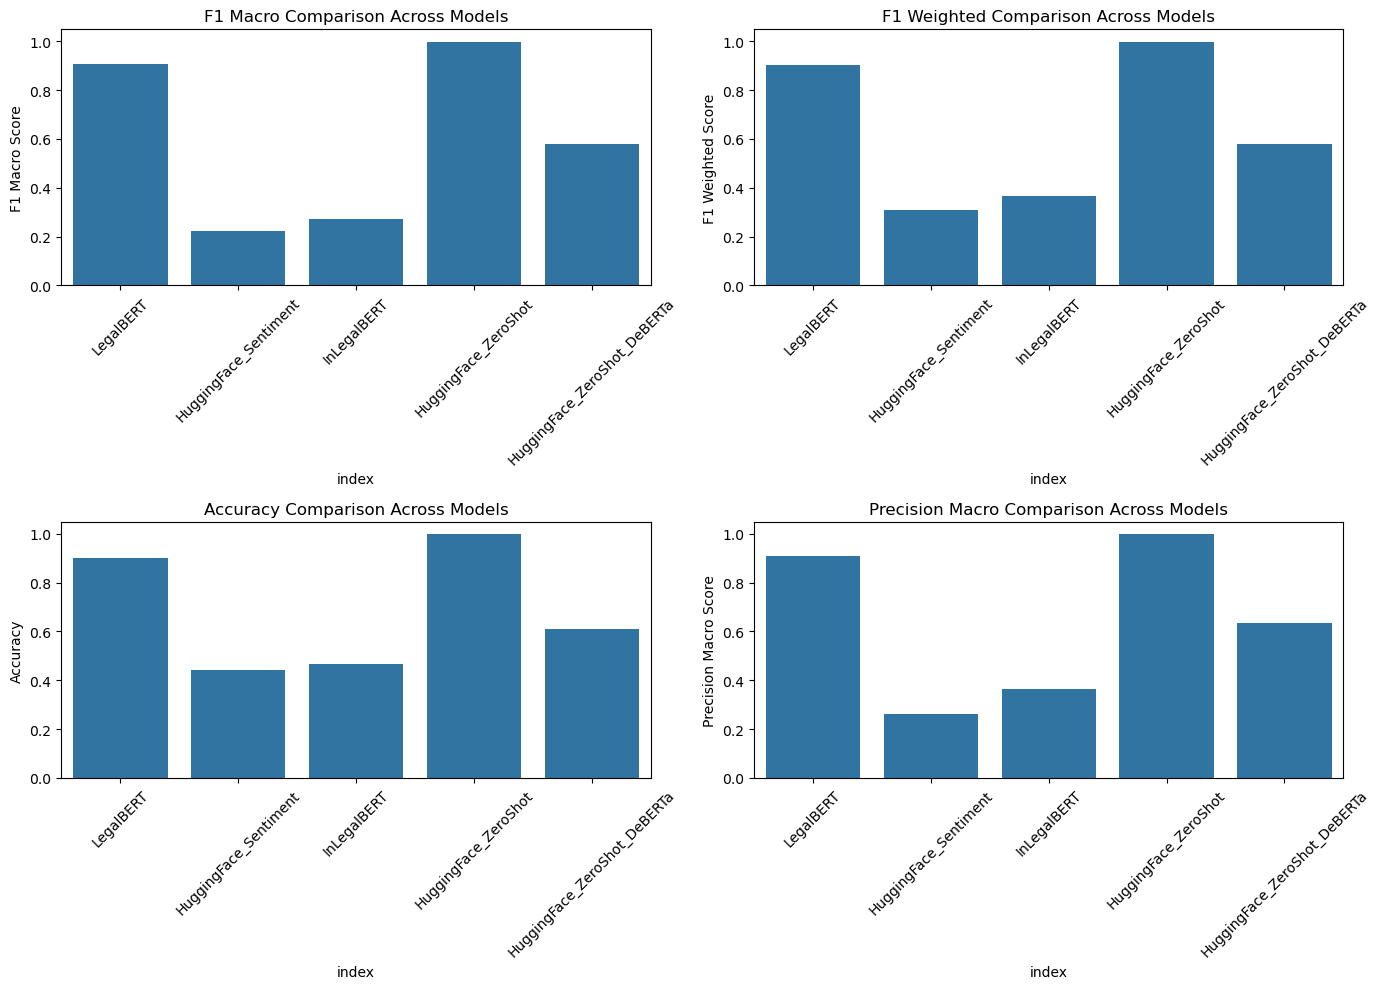


✅ Comparison done — metrics and plots saved.
Saved files: model_comparison_metrics.json, comparison_summary.csv, all_metrics_comparison.png, and individual confusion matrix files.


In [35]:
# --- Plot summary bar charts ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(data=df_metrics.reset_index(), x="index", y="f1_macro", ax=axes[0,0])
axes[0,0].set_title("F1 Macro Comparison Across Models")
axes[0,0].set_ylabel("F1 Macro Score")
axes[0,0].tick_params(axis='x', rotation=45)

sns.barplot(data=df_metrics.reset_index(), x="index", y="f1_weighted", ax=axes[0,1])
axes[0,1].set_title("F1 Weighted Comparison Across Models")
axes[0,1].set_ylabel("F1 Weighted Score")
axes[0,1].tick_params(axis='x', rotation=45)

sns.barplot(data=df_metrics.reset_index(), x="index", y="accuracy", ax=axes[1,0])
axes[1,0].set_title("Accuracy Comparison Across Models")
axes[1,0].set_ylabel("Accuracy")
axes[1,0].tick_params(axis='x', rotation=45)

sns.barplot(data=df_metrics.reset_index(), x="index", y="precision_macro", ax=axes[1,1])
axes[1,1].set_title("Precision Macro Comparison Across Models")
axes[1,1].set_ylabel("Precision Macro Score")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("all_metrics_comparison.png")
plt.show() # Display the plot in the notebook

print("\n✅ Comparison done — metrics and plots saved.")
print(f"Saved files: model_comparison_metrics.json, comparison_summary.csv, all_metrics_comparison.png, and individual confusion matrix files.")